# PCA - Erdbeere Gesamt v2 (Without Threshold)

**Version:** v2 - no OAV / olfactory threshold used.
**Pipeline:** Remove ignore-list substances (CAS-based) -> normalise Totalmenge per recipe -> PCA.
**Dataset:** `data/gold/Third_Trial_Set_PDM Erdbeere Gesamt 8-5-2026.csv`
**Outputs:** `outputs/pca_v2_without_threshold_*`


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────────
BASE      = Path('..')
DATA_PATH = BASE / 'data/gold/Third_Trial_Set_PDM Erdbeere Gesamt 8-5-2026.csv'
OUT_DIR   = BASE / 'outputs'
OUT_DIR.mkdir(exist_ok=True)
IGNORE_PATH = BASE / 'data/gold/ignone_substances.csv'

print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Load & Clean Data

In [2]:
def parse_de_float(val):
    """Parse German-locale floats (comma as decimal separator, scientific notation)."""
    if pd.isna(val):
        return float('nan')
    s = str(val).strip().replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return float('nan')

df = pd.read_csv(DATA_PATH, dtype=str)
df['Totalmenge'] = df['Totalmenge'].apply(parse_de_float)
df['Threshold']  = df['Threshold'].apply(parse_de_float)

print(f'Raw rows: {len(df):,}')
print(f'Unique recipes (Rez.-Nr.): {df["Rez.-Nr."].nunique()}')
print(f'Unique ingredients (Ident): {df["Ident"].nunique()}')
print(f'Unique CAS numbers: {df["CAS-Nr."].nunique()}')

# Collect all odour types
all_ot = pd.concat([
    df['Odour-Type 1'].dropna(),
    df['Odour-Type 2'].dropna(),
    df['Odour-Type 3'].dropna()
]).unique()
print(f'\nOdour types ({len(all_ot)}): {sorted(all_ot)}')

Raw rows: 3,369
Unique recipes (Rez.-Nr.): 130
Unique ingredients (Ident): 338
Unique CAS numbers: 231

Odour types (20): ['alcoholic', 'alliaceous', 'animalic', 'balsamic', 'citrus', 'dairy', 'ethereal', 'exotic', 'floral', 'fresh', 'fruity', 'green', 'herbal', 'minty', 'nutty', 'odorless', 'peppery', 'unpleasant', 'warm', 'woody']


In [3]:
# ── Apply ignore list ────────────────────────────────────────────────────────
if IGNORE_PATH.exists():
    ign             = pd.read_csv(IGNORE_PATH)
    ign_idents      = set(ign["Ident"].dropna().astype(str).str.strip())
    names_to_ignore = {str(n).lower().strip() for n in ign["Name"]}
    # Zero by Ident and Name first
    mask = (
        df["Ident"].astype(str).str.strip().isin(ign_idents) |
        df["Name"].str.lower().str.strip().isin(names_to_ignore)
    )
    # Derive CAS numbers of every matched row and zero ALL rows sharing that CAS
    # (catches alternate Idents of the same substance, e.g. R01946 for Triethylcitrat)
    cas_to_ignore = set(df.loc[mask, "CAS-Nr."].dropna().astype(str).str.strip())
    df.loc[df["CAS-Nr."].astype(str).str.strip().isin(cas_to_ignore), "Totalmenge"] = 0.0
    print(f"Ignored idents: {len(ign_idents)} | Ignored CAS numbers: {len(cas_to_ignore)}")
else:
    print("No ignore list found — all ingredients included.")


Ignored idents: 10 | Ignored CAS numbers: 6


In [4]:
# -- Normalize Totalmenge per recipe (no threshold, no OAV) ------------------
# After ignore-list zeroing, keep only rows with positive Totalmenge then
# express each ingredient as a relative proportion within its recipe.

df_t = df[df["Totalmenge"] > 0].copy()

per_recipe_sum = df_t.groupby("Rez.-Nr.")["Totalmenge"].transform("sum")
df_t["Norm_Totalmenge"] = df_t["Totalmenge"] / per_recipe_sum

print(f"Rows with positive Totalmenge: {len(df_t):,}")
print(f"Recipes after filtering      : {df_t['Rez.-Nr.'].nunique()}")
print(f"Unique CAS numbers retained  : {df_t['CAS-Nr.'].nunique()}")
print()
print("Norm_Totalmenge distribution:")
print(df_t["Norm_Totalmenge"].describe().round(5))


Rows with positive Totalmenge: 3,155
Recipes after filtering      : 130
Unique CAS numbers retained  : 225

Norm_Totalmenge distribution:
count    3155.00000
mean        0.04120
std         0.10592
min         0.00000
25%         0.00093
50%         0.00661
75%         0.03654
max         1.00000
Name: Norm_Totalmenge, dtype: float64


In [5]:
# -- Build Recipe x CAS Normalized Totalmenge matrix --------------------------
pivot_oav = df_t.pivot_table(
    index="Rez.-Nr.", columns="CAS-Nr.",
    values="Norm_Totalmenge", aggfunc="sum", fill_value=0
)
print(f"Recipe x CAS matrix       : {pivot_oav.shape}")
print(f"Avg CAS per recipe        : {(pivot_oav > 0).sum(axis=1).mean():.1f}")
print(f"Matrix value range        : {pivot_oav.values.min():.5f} - {pivot_oav.values.max():.5f}")

# No log transformation -- normalised proportions are already on a comparable scale
X_oav = pivot_oav.values.copy()


Recipe x CAS matrix       : (129, 225)
Avg CAS per recipe        : 23.8
Matrix value range        : 0.00000 - 0.78706


In [6]:
# -- Build Recipe x OdourType Normalized Totalmenge profile ------------------
rows = []
for _, row in df_t.iterrows():
    for col in ["Odour-Type 1", "Odour-Type 2", "Odour-Type 3"]:
        ot = row[col]
        if pd.notna(ot):
            rows.append({"Recipe": row["Rez.-Nr."], "OdourType": ot,
                         "Norm_Totalmenge": row["Norm_Totalmenge"]})

ot_df    = pd.DataFrame(rows)
pivot_ot = ot_df.groupby(["Recipe", "OdourType"])["Norm_Totalmenge"].sum().unstack(fill_value=0)
print(f"Recipe x OdourType matrix : {pivot_ot.shape}")
print(f"Odour types               : {pivot_ot.columns.tolist()}")

# No log transformation
X_ot = pivot_ot.values.copy()

dom_ot_series = pivot_ot.idxmax(axis=1)
print("\nDominant odour type distribution:")
print(dom_ot_series.value_counts())


Recipe x OdourType matrix : (130, 20)
Odour types               : ['alcoholic', 'alliaceous', 'animalic', 'balsamic', 'citrus', 'dairy', 'ethereal', 'exotic', 'floral', 'fresh', 'fruity', 'green', 'herbal', 'minty', 'nutty', 'odorless', 'peppery', 'unpleasant', 'warm', 'woody']

Dominant odour type distribution:
fruity      81
odorless    36
fresh        7
warm         6
Name: count, dtype: int64


In [7]:
# -- Ingredient Statistics: Frequency & Average (after removal + normalisation) --
cas_name_full = df.groupby("CAS-Nr.")["Name"].first().to_dict()

# Frequency = fraction of recipes where ingredient is present (proportion > 0)
freq      = (pivot_oav > 0).mean(axis=0)
n_recipes = (pivot_oav > 0).sum(axis=0)

# Average normalised proportion among recipes that contain the ingredient
avg_present_mat = pivot_oav.copy()
avg_present_mat[avg_present_mat == 0] = np.nan
avg_when_present = avg_present_mat.mean(axis=0)

# Average normalised proportion across ALL recipes (including zeros)
avg_all = pivot_oav.mean(axis=0)

ing_stats = pd.DataFrame({
    "CAS":                   pivot_oav.columns,
    "Ingredient":            [cas_name_full.get(c, c) for c in pivot_oav.columns],
    "Frequency":             freq.values.round(4),
    "Recipes_Count":         n_recipes.values,
    "Avg_Norm_When_Present": avg_when_present.values.round(6),
    "Avg_Norm_All_Recipes":  avg_all.values.round(6),
}).sort_values("Frequency", ascending=False).reset_index(drop=True)

print(f"Ingredient statistics for {len(ing_stats)} unique CAS numbers "
      f"across {len(pivot_oav)} recipes")
print()
print(ing_stats.head(30).to_string(index=False))

ing_stats.to_csv(OUT_DIR / "pca_v2_ingredient_statistics.csv", index=False)
ing_stats.to_excel(OUT_DIR / "pca_v2_ingredient_statistics.xlsx", index=False)
print("\nExported: pca_v2_ingredient_statistics.csv / .xlsx")


Ingredient statistics for 225 unique CAS numbers across 129 recipes

       CAS                                      Ingredient  Frequency  Recipes_Count  Avg_Norm_When_Present  Avg_Norm_All_Recipes
  105-54-4                       Ethylbutyrat Kosher Halal     0.9922            128               0.093956              0.093228
  706-14-9                   gamma-Decalacton Kosher Halal     0.9302            120               0.038739              0.036037
  123-66-0                             Ethylhexanoat Halal     0.9225            119               0.036157              0.033354
 7452-79-1              Ethyl-2-methylbutyrat Kosher Halal     0.9147            118               0.048705              0.044552
  928-96-1                   cis-3-Hexen-1-ol Halal Kosher     0.8992            116               0.088893              0.079935
  116-53-0                2-Methylbuttersäure Halal Kosher     0.8140            105               0.063624              0.051787
 3658-77-3           

## 2 · PCA on Normalised Totalmenge Fingerprint (recipes x CAS)


In [8]:
# ── Fit PCA ─────────────────────────────────────────────────────────────────
scaler_oav = StandardScaler()
X_oav_scaled = scaler_oav.fit_transform(X_oav)

n_components = min(10, X_oav.shape[1], X_oav.shape[0])
pca_oav = PCA(n_components=n_components, random_state=42)
scores_oav = pca_oav.fit_transform(X_oav_scaled)

ev = pca_oav.explained_variance_ratio_ * 100
print('Explained variance per component:')
for i, v in enumerate(ev):
    print(f'  PC{i+1}: {v:.1f}%  (cumulative: {ev[:i+1].sum():.1f}%)')

Explained variance per component:
  PC1: 5.2%  (cumulative: 5.2%)
  PC2: 4.8%  (cumulative: 10.0%)
  PC3: 4.0%  (cumulative: 14.0%)
  PC4: 3.7%  (cumulative: 17.7%)
  PC5: 3.3%  (cumulative: 21.0%)
  PC6: 3.1%  (cumulative: 24.1%)
  PC7: 3.0%  (cumulative: 27.1%)
  PC8: 2.9%  (cumulative: 30.0%)
  PC9: 2.8%  (cumulative: 32.7%)
  PC10: 2.6%  (cumulative: 35.4%)


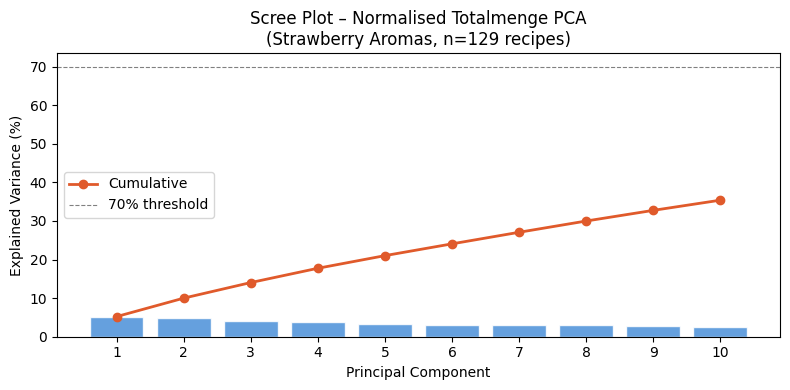

Saved: pca_v2_scree_norm.png


In [9]:
# ── Scree plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(ev)+1), ev, color='#4A90D9', alpha=0.85, edgecolor='white')
ax.plot(range(1, len(ev)+1), np.cumsum(ev), 'o-', color='#E05A2B', lw=2, label='Cumulative')
ax.axhline(70, ls='--', color='grey', lw=0.8, label='70% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot – Normalised Totalmenge PCA\n(Strawberry Aromas, n=129 recipes)')
ax.set_xticks(range(1, len(ev)+1))
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_scree_norm.png', dpi=150)
plt.show()
print('Saved: pca_v2_scree_norm.png')

In [10]:
# ── Colour palette for odour types ──────────────────────────────────────────
ODOUR_PALETTE = {
    'fruity':     '#E05A2B',
    'floral':     '#D44F9A',
    'green':      '#4CAF50',
    'fresh':      '#29B6F6',
    'citrus':     '#FFA726',
    'dairy':      '#F3E5AB',
    'warm':       '#A1662F',
    'nutty':      '#8D6E63',
    'balsamic':   '#7B1FA2',
    'woody':      '#5D4037',
    'ethereal':   '#90CAF9',
    'herbal':     '#66BB6A',
    'minty':      '#26C6DA',
    'exotic':     '#FF7043',
    'animalic':   '#795548',
    'unpleasant': '#9E9E9E',
    'peppery':    '#F44336',
    'alcoholic':  '#3F51B5',
    'alliaceous': '#8BC34A',
    'odorless':   '#EEEEEE',
}

# Map recipes to their dominant odour type
recipes_oav = list(pivot_oav.index)

# Get dominant OT for recipes that have OT data
# Some recipes in pivot_oav may not appear in pivot_ot (no odour type info)
dom_ot_dict = dom_ot_series.to_dict()
dom_ot_labels = [dom_ot_dict.get(r, 'unknown') for r in recipes_oav]
colors_oav = [ODOUR_PALETTE.get(ot, '#BBBBBB') for ot in dom_ot_labels]

print('Dominant odour types assigned to', len(recipes_oav), 'recipes')
from collections import Counter
print(Counter(dom_ot_labels))

Dominant odour types assigned to 129 recipes
Counter({'fruity': 81, 'odorless': 36, 'fresh': 6, 'warm': 6})


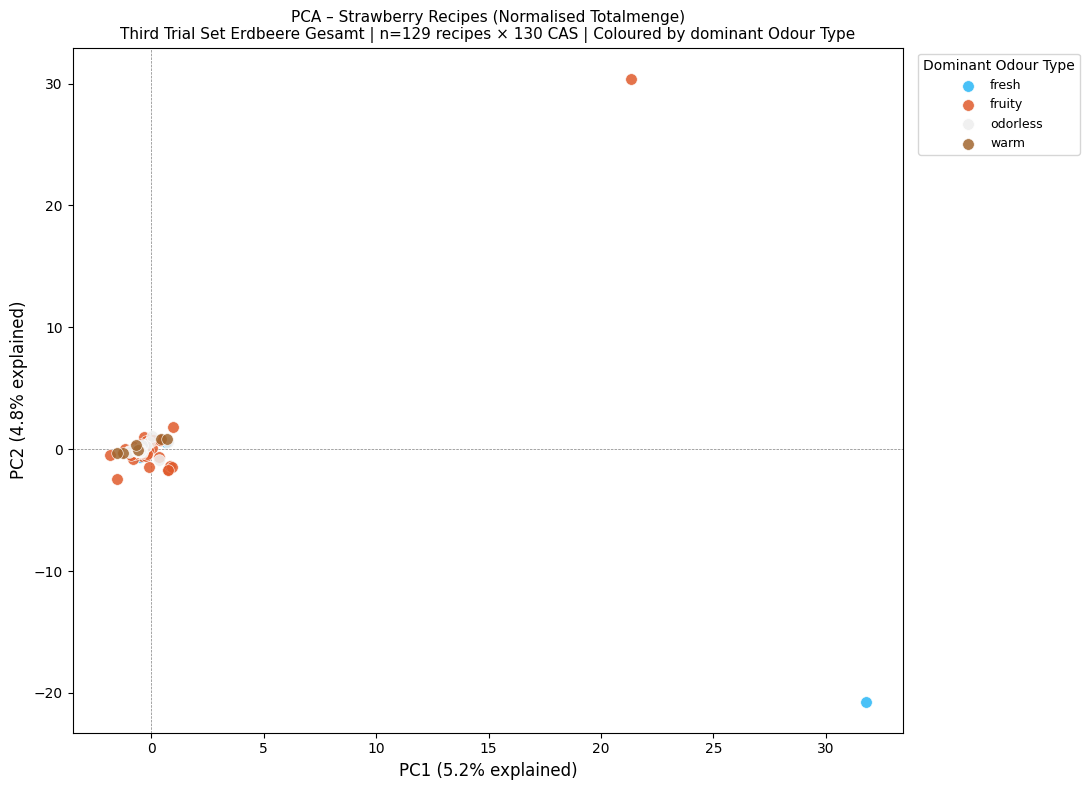

Saved: pca_v2_pc1pc2_norm.png


In [11]:
# ── PC1 vs PC2 scatter – coloured by dominant odour type ────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

for ot in sorted(set(dom_ot_labels)):
    mask = np.array(dom_ot_labels) == ot
    ax.scatter(
        scores_oav[mask, 0], scores_oav[mask, 1],
        c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
        label=ot, s=70, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3
    )

ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({ev[0]:.1f}% explained)', fontsize=12)
ax.set_ylabel(f'PC2 ({ev[1]:.1f}% explained)', fontsize=12)
ax.set_title(
    'PCA – Strawberry Recipes (Normalised Totalmenge)\n'
    f'Third Trial Set Erdbeere Gesamt | n={len(recipes_oav)} recipes × 130 CAS | Coloured by dominant Odour Type',
    fontsize=11
)
ax.legend(title='Dominant Odour Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_pc1pc2_norm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_pc1pc2_norm.png')

## 3 · Biplot – Top Ingredient Loadings

In [12]:
# ── Build ingredient name lookup ─────────────────────────────────────────────
cas_name = df.groupby('CAS-Nr.')['Name'].first().to_dict()

# Loadings matrix: shape (n_components, n_features)
loadings = pca_oav.components_  # (10, 130)
cas_labels = pivot_oav.columns.tolist()

# Identify top contributors to PC1 and PC2
N_ARROWS = 12
importance = np.sqrt(loadings[0]**2 + loadings[1]**2)
top_idx = np.argsort(importance)[::-1][:N_ARROWS]

print(f'Top {N_ARROWS} ingredients driving PC1+PC2:')
for i in top_idx:
    cas = cas_labels[i]
    name = cas_name.get(cas, cas)
    print(f'  {cas:15s} {name[:45]:45s}  L1={loadings[0,i]:+.3f}  L2={loadings[1,i]:+.3f}')

Top 12 ingredients driving PC1+PC2:
  3390-12-3       Acetaldehyd PG acetal                          L1=+0.161  L2=+0.250
  23726-92-3      beta-Damascon Halal                            L1=+0.161  L2=+0.250
  104-20-1        Himbeerketonmethylether Halal                  L1=+0.161  L2=+0.250
  123-11-5        Anisaldehyd Halal                              L1=+0.161  L2=+0.250
  127-41-3        alpha-Ionon Halal Kosher                       L1=+0.162  L2=+0.249
  141-12-8        Nerylacetat Halal                              L1=+0.160  L2=+0.250
  100-51-6        Benzylalkohol Halal                            L1=+0.170  L2=+0.242
  103-37-7        Benzylbutyrat                                  L1=+0.159  L2=+0.249
  124-19-6        Nonanal, natürlich Halal                       L1=+0.239  L2=-0.170
  90045-28-6      Wintergrün-Öl China                            L1=+0.239  L2=-0.170
  1192-62-7       2-Acetylfuran, natürlich                       L1=+0.239  L2=-0.170
  119-84-6        

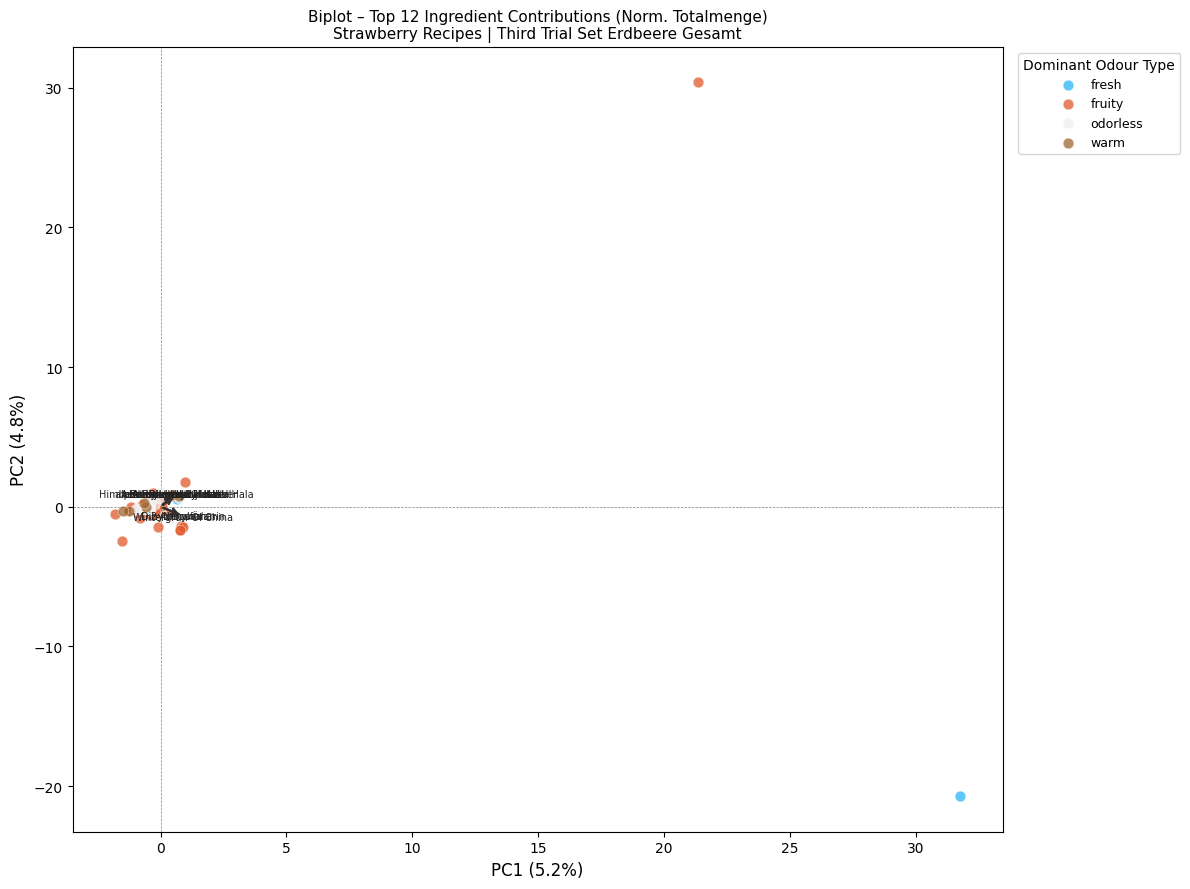

Saved: pca_v2_biplot_norm.png


In [13]:
# ── Biplot ───────────────────────────────────────────────────────────────────
SCALE = 3.5  # scale factor to make arrows visible

fig, ax = plt.subplots(figsize=(12, 9))

# Scatter recipes
for ot in sorted(set(dom_ot_labels)):
    mask = np.array(dom_ot_labels) == ot
    ax.scatter(
        scores_oav[mask, 0], scores_oav[mask, 1],
        c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
        label=ot, s=60, alpha=0.75, edgecolors='white', linewidths=0.4, zorder=3
    )

# Arrow overlays for top ingredients
for i in top_idx:
    cas = cas_labels[i]
    name = cas_name.get(cas, cas)
    # Shorten name for readability
    short = name.split(',')[0][:28]
    lx, ly = loadings[0, i] * SCALE, loadings[1, i] * SCALE
    ax.annotate(
        '', xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='#333333', lw=1.4)
    )
    ax.text(lx * 1.08, ly * 1.08, short, fontsize=7, color='#222222',
            ha='center', va='center')

ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)', fontsize=12)
ax.set_title(
    f'Biplot – Top {N_ARROWS} Ingredient Contributions (Norm. Totalmenge)\n'
    'Strawberry Recipes | Third Trial Set Erdbeere Gesamt',
    fontsize=11
)
ax.legend(title='Dominant Odour Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_biplot_norm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_biplot_norm.png')

## 4 · PCA on Odour-Type Profile

In [14]:
# ── Fit PCA on odour-type matrix ─────────────────────────────────────────────
scaler_ot = StandardScaler()
X_ot_scaled = scaler_ot.fit_transform(X_ot)

n_comp_ot = min(10, X_ot.shape[1], X_ot.shape[0])
pca_ot = PCA(n_components=n_comp_ot, random_state=42)
scores_ot = pca_ot.fit_transform(X_ot_scaled)

ev_ot = pca_ot.explained_variance_ratio_ * 100
print('Explained variance (Odour-Type PCA):')
for i, v in enumerate(ev_ot):
    print(f'  PC{i+1}: {v:.1f}%  (cumulative: {ev_ot[:i+1].sum():.1f}%)')

Explained variance (Odour-Type PCA):
  PC1: 18.4%  (cumulative: 18.4%)
  PC2: 11.0%  (cumulative: 29.4%)
  PC3: 8.3%  (cumulative: 37.7%)
  PC4: 7.8%  (cumulative: 45.5%)
  PC5: 6.2%  (cumulative: 51.7%)
  PC6: 5.5%  (cumulative: 57.2%)
  PC7: 5.3%  (cumulative: 62.5%)
  PC8: 5.2%  (cumulative: 67.8%)
  PC9: 5.1%  (cumulative: 72.8%)
  PC10: 4.8%  (cumulative: 77.7%)


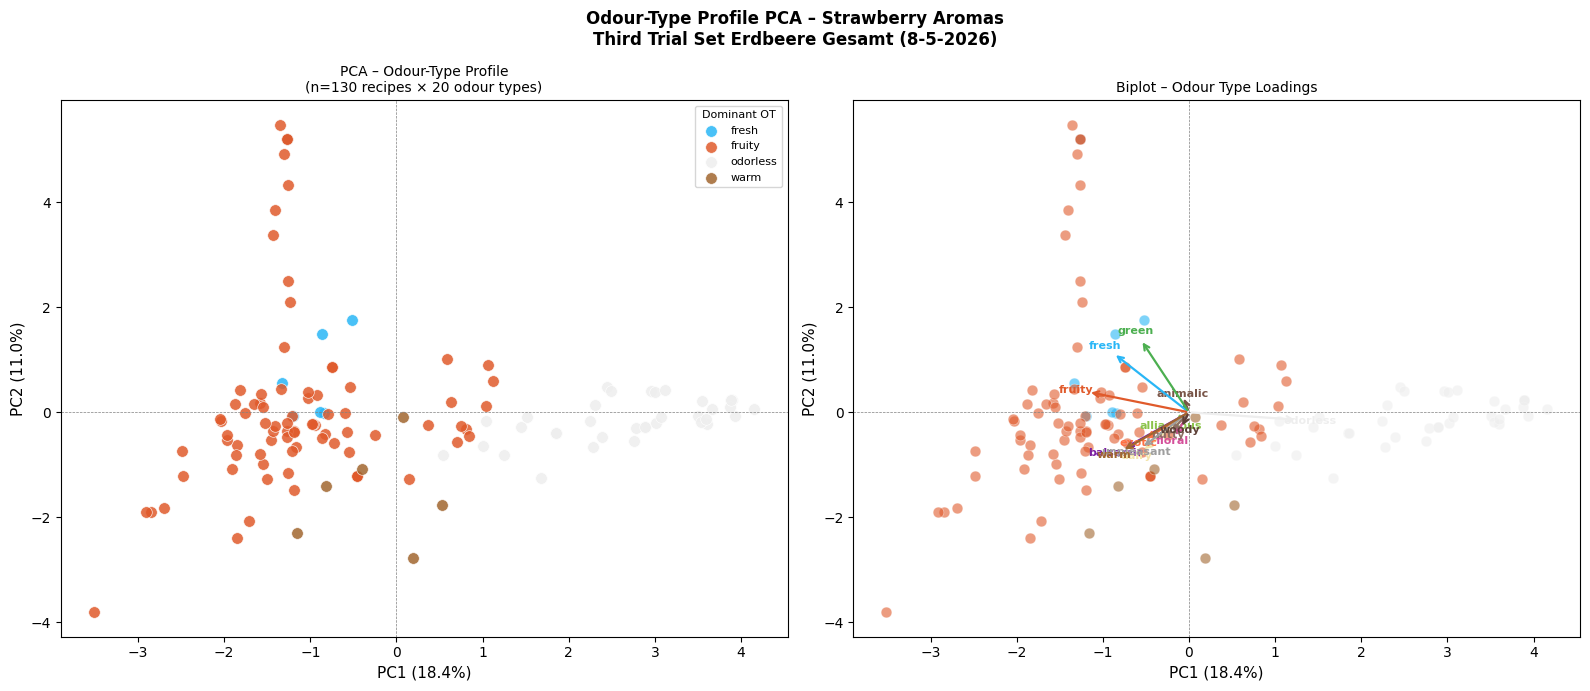

Saved: pca_v1_odourtype_biplot.png


In [15]:
# ── PC1 vs PC2 – Odour Type space ────────────────────────────────────────────
recipes_ot = list(pivot_ot.index)
dom_ot_ot  = [dom_ot_dict.get(r, 'unknown') for r in recipes_ot]
colors_ot  = [ODOUR_PALETTE.get(ot, '#BBBBBB') for ot in dom_ot_ot]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Odour-type PCA scatter ---
ax = axes[0]
for ot in sorted(set(dom_ot_ot)):
    mask = np.array(dom_ot_ot) == ot
    ax.scatter(
        scores_ot[mask, 0], scores_ot[mask, 1],
        c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
        label=ot, s=70, alpha=0.85, edgecolors='white', linewidths=0.5
    )
ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({ev_ot[0]:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev_ot[1]:.1f}%)', fontsize=11)
ax.set_title('PCA – Odour-Type Profile\n(n={} recipes × 20 odour types)'.format(len(recipes_ot)), fontsize=10)
ax.legend(title='Dominant OT', fontsize=8, title_fontsize=8)

# --- Right: Odour-type loadings biplot ---
ax2 = axes[1]
for ot in sorted(set(dom_ot_ot)):
    mask = np.array(dom_ot_ot) == ot
    ax2.scatter(
        scores_ot[mask, 0], scores_ot[mask, 1],
        c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
        s=60, alpha=0.6, edgecolors='white', linewidths=0.4
    )

SCALE_OT = 2.5
loadings_ot = pca_ot.components_
ot_cols = list(pivot_ot.columns)
for j, ot_name in enumerate(ot_cols):
    lx, ly = loadings_ot[0, j] * SCALE_OT, loadings_ot[1, j] * SCALE_OT
    if abs(lx) + abs(ly) < 0.3:  # skip tiny arrows
        continue
    ax2.annotate(
        '', xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color=ODOUR_PALETTE.get(ot_name,'#555'), lw=1.6)
    )
    ax2.text(lx * 1.12, ly * 1.12, ot_name, fontsize=8,
             color=ODOUR_PALETTE.get(ot_name,'#333'),
             ha='center', va='center', fontweight='bold')

ax2.axhline(0, color='grey', lw=0.5, ls='--')
ax2.axvline(0, color='grey', lw=0.5, ls='--')
ax2.set_xlabel(f'PC1 ({ev_ot[0]:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({ev_ot[1]:.1f}%)', fontsize=11)
ax2.set_title('Biplot – Odour Type Loadings', fontsize=10)

fig.suptitle(
    'Odour-Type Profile PCA – Strawberry Aromas\nThird Trial Set Erdbeere Gesamt (8-5-2026)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v1_odourtype_biplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v1_odourtype_biplot.png')

## 5 · PC1–PC3 Dashboard (3 Panel)

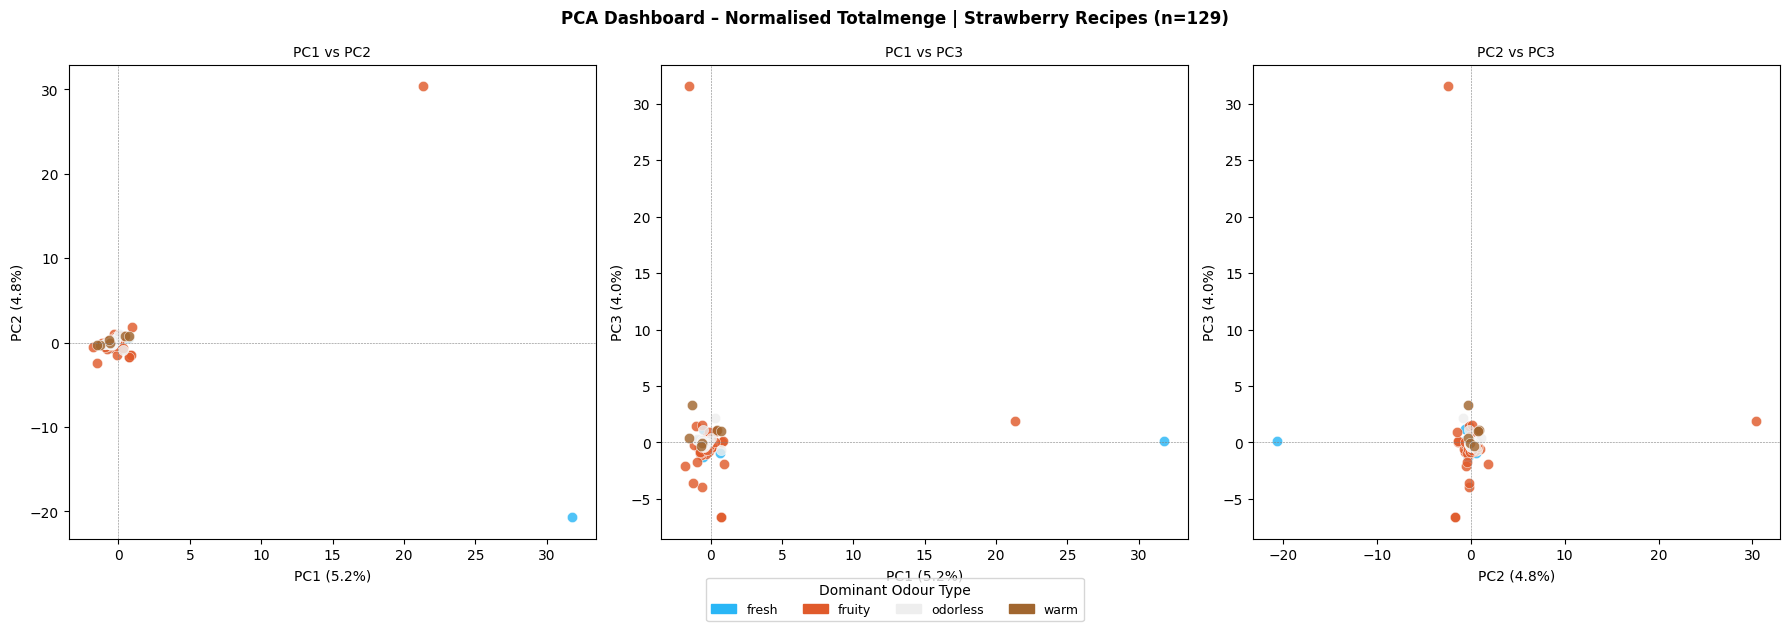

Saved: pca_v2_dashboard_pc123.png


In [16]:
# ── PC1 vs PC2, PC1 vs PC3, PC2 vs PC3 ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pairs = [(0, 1), (0, 2), (1, 2)]

for ax, (i, j) in zip(axes, pairs):
    for ot in sorted(set(dom_ot_labels)):
        mask = np.array(dom_ot_labels) == ot
        ax.scatter(
            scores_oav[mask, i], scores_oav[mask, j],
            c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
            label=ot, s=55, alpha=0.82, edgecolors='white', linewidths=0.4
        )
    ax.axhline(0, color='grey', lw=0.4, ls='--')
    ax.axvline(0, color='grey', lw=0.4, ls='--')
    ax.set_xlabel(f'PC{i+1} ({ev[i]:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC{j+1} ({ev[j]:.1f}%)', fontsize=10)
    ax.set_title(f'PC{i+1} vs PC{j+1}', fontsize=10)

# Shared legend
handles = [
    mpatches.Patch(color=ODOUR_PALETTE.get(ot,'#BBBBBB'), label=ot)
    for ot in sorted(set(dom_ot_labels))
]
fig.legend(handles=handles, title='Dominant Odour Type',
           loc='lower center', ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle(
    'PCA Dashboard – Normalised Totalmenge | Strawberry Recipes (n=129)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_dashboard_pc123.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_dashboard_pc123.png')

## 6 · Loading Heatmap – Which Ingredients Drive Which Components

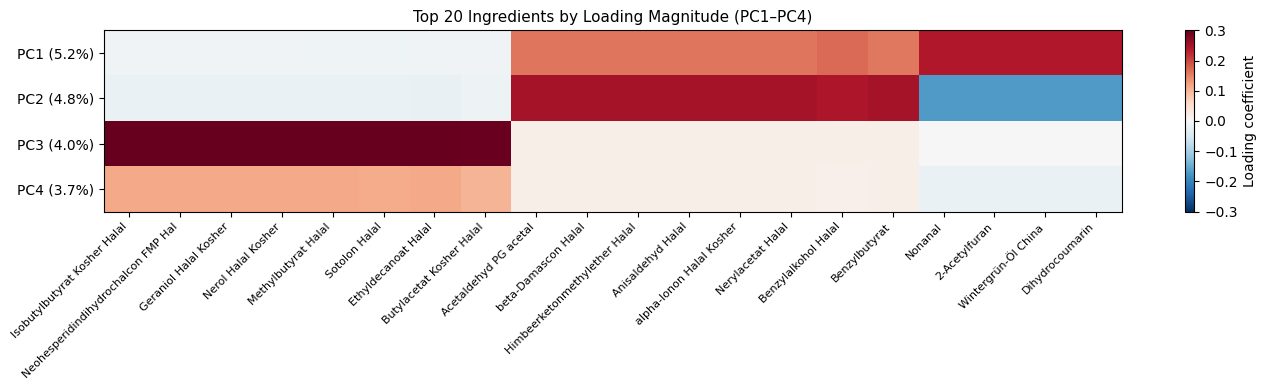

Saved: pca_v2_loading_heatmap.png


In [17]:
# Top 20 ingredients by combined importance across PC1..PC4
N_TOP = 20
N_PC  = min(4, pca_oav.n_components_)

importance_4 = np.sqrt((loadings[:N_PC]**2).sum(axis=0))
top20_idx = np.argsort(importance_4)[::-1][:N_TOP]

top20_cas   = [cas_labels[i] for i in top20_idx]
top20_names = [cas_name.get(c, c).split(',')[0][:35] for c in top20_cas]
loading_mat = loadings[:N_PC][:, top20_idx]  # (N_PC, N_TOP)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(loading_mat, aspect='auto', cmap='RdBu_r', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(N_TOP))
ax.set_xticklabels(top20_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(N_PC))
ax.set_yticklabels([f'PC{k+1} ({ev[k]:.1f}%)' for k in range(N_PC)], fontsize=10)
plt.colorbar(im, ax=ax, label='Loading coefficient')
ax.set_title(f'Top {N_TOP} Ingredients by Loading Magnitude (PC1–PC{N_PC})', fontsize=11)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_loading_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_loading_heatmap.png')

## 7 · Recipe Scores Table

In [18]:
# Full scores table for reference / export
scores_df = pd.DataFrame(
    scores_oav[:, :5],
    index=pivot_oav.index,
    columns=[f'PC{i+1}' for i in range(5)]
)
scores_df['Dominant_OT'] = dom_ot_labels
scores_df.index.name = 'Rez.-Nr.'

print('PCA Scores (first 15 recipes):')
print(scores_df.head(15).round(3).to_string())

scores_df.to_csv(OUT_DIR / 'pca_v2_scores.csv')
print('\nFull table saved: pca_v2_scores.csv')

PCA Scores (first 15 recipes):
              PC1     PC2    PC3    PC4    PC5 Dominant_OT
Rez.-Nr.                                                  
185.028     0.650   0.553 -0.910 -1.447 -9.559       fresh
185.043P   -0.509  -0.134  0.063 -1.642 -1.652    odorless
185.044    -0.509  -0.134  0.063 -1.642 -1.652    odorless
185.046    -0.632  -0.155  0.002 -0.890 -0.043       fresh
185.086    -0.772  -0.072  0.024 -1.561 -0.577    odorless
185.090P   -0.097   0.625  0.168 -1.214 -0.450    odorless
185.091    -0.522  -0.123  0.028 -1.105 -0.473    odorless
185.133    -0.576  -0.090  0.029 -1.327 -0.497    odorless
185.178HP  -0.395  -0.584 -0.867 -0.130 -0.877      fruity
185.237H   -0.425   0.210 -0.014 -0.825 -0.206    odorless
185.239    -0.582  -0.245  0.004 -1.106 -0.653      fruity
185.267    -0.501  -0.210  1.118 -0.738 -0.189    odorless
185.291    -0.491  -0.089 -0.062 -0.920 -0.602      fruity
185.294    -0.618  -0.014 -0.057 -1.122 -0.461      fruity
185.309P   21.336  30.386

## Summary

| | Value |
|---|---|
| Version | v2 - without threshold |
| Pipeline | Remove ignore list -> Normalise per recipe -> PCA |
| Features | CAS-level normalised Totalmenge |
| Log transform | None |
| Top-N per recipe | 20 |
| Outputs | `outputs/pca_v2_*` |


In [19]:
# ── Pre-compute full contribution tensor: (n_recipes, n_pc, n_cas) ──────────
# contrib[r, k, i] = X_oav_scaled[r,i] * loadings[k,i]
N_PC_ATTR = 4
contrib = X_oav_scaled[:, np.newaxis, :] * loadings[np.newaxis, :N_PC_ATTR, :]  # (R, K, I)

recipe_idx_map = {r: idx for idx, r in enumerate(recipes_oav)}
cas_name       = df.groupby('CAS-Nr.')['Name'].first().to_dict()

print(f'Contribution tensor shape: {contrib.shape}  (recipes × PCs × ingredients)')
print('Ready for recipe lookup.')

Contribution tensor shape: (129, 4, 225)  (recipes × PCs × ingredients)
Ready for recipe lookup.


In [20]:
def explain_recipe(rez_nr, n_top=8, plot=True):
    """
    Given a recipe (Rez.-Nr.), print and optionally plot:
      - its PC1–PC4 scores
      - the top n_top ingredients driving each PC (by signed contribution)
      - the 8 nearest recipes in PCA space
    """
    if rez_nr not in recipe_idx_map:
        print(f'Recipe {rez_nr!r} not found.')
        print('Available (first 10):', sorted(recipe_idx_map.keys())[:10])
        return

    r_idx   = recipe_idx_map[rez_nr]
    r_scores = scores_oav[r_idx, :N_PC_ATTR]
    r_contrib = contrib[r_idx]          # shape (N_PC_ATTR, n_cas)
    dom_ot  = dom_ot_labels[r_idx]

    print('══════════════════════════════════════════════════')
    print(f'  Recipe: {rez_nr}   |   Dominant Odour Type: {dom_ot}')
    print('══════════════════════════════════════════════════')
    for k in range(N_PC_ATTR):
        print(f'  PC{k+1} score: {r_scores[k]:+.3f}  (explains {ev[k]:.1f}% of total variance)')
    print()

    # ── Top ingredients per PC ────────────────────────────────────────────
    for k in range(N_PC_ATTR):
        c_vec   = r_contrib[k]
        top_idx_k = np.argsort(np.abs(c_vec))[::-1][:n_top]
        print(f'  ── PC{k+1}: top {n_top} ingredient drivers ──')
        for i in top_idx_k:
            cas  = cas_labels[i]
            name = cas_name.get(cas, cas).split(',')[0][:40]
            oav  = pivot_oav.iloc[r_idx, i]
            sign = '+' if c_vec[i] >= 0 else '-'
            print(f'    {sign}  contrib={c_vec[i]:+.4f}  OAV={oav:.5f}  {name} ({cas})')
        print()

    # ── Nearest recipes ───────────────────────────────────────────────────
    dists   = np.linalg.norm(scores_oav - scores_oav[r_idx], axis=1)
    nn_idx  = np.argsort(dists)[1:9]
    print('  ── 8 nearest recipes in PCA space ──')
    for ni in nn_idx:
        print(f'    {recipes_oav[ni]:12s}  dist={dists[ni]:.3f}'
              f'  PC1={scores_oav[ni,0]:+.2f}  PC2={scores_oav[ni,1]:+.2f}'
              f'  ({dom_ot_labels[ni]})')

    # ── Bar chart: PC1 & PC2 ingredient contributions ────────────────────
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax_i, k in enumerate([0, 1]):
            c_vec     = r_contrib[k]
            top_idx_k = np.argsort(np.abs(c_vec))[::-1][:n_top]
            names_k   = [cas_name.get(cas_labels[i], cas_labels[i]).split(',')[0][:32]
                         for i in top_idx_k]
            vals_k    = [c_vec[i] for i in top_idx_k]
            bar_colors = ['#E05A2B' if v >= 0 else '#4A90D9' for v in vals_k]
            ax = axes[ax_i]
            ax.barh(range(n_top), vals_k[::-1], color=bar_colors[::-1],
                    edgecolor='white', height=0.7)
            ax.set_yticks(range(n_top))
            ax.set_yticklabels(names_k[::-1], fontsize=8)
            ax.axvline(0, color='grey', lw=0.8)
            ax.set_xlabel('Contribution to PC score')
            ax.set_title(f'PC{k+1} ({ev[k]:.1f}%) — recipe {rez_nr}')
        fig.suptitle(
            f'Ingredient Attribution  |  Recipe {rez_nr}  |  Dominant OT: {dom_ot}',
            fontsize=11, fontweight='bold'
        )
        plt.tight_layout()
        safe = str(rez_nr).replace('.', '-').replace(' ', '_')
        fname = OUT_DIR / f'pca_v1_explain_{safe}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname.name}')

print('explain_recipe() defined.')
print('Usage:  explain_recipe(recipes_oav[0])')

explain_recipe() defined.
Usage:  explain_recipe(recipes_oav[0])


In [21]:
def explain_recipe(rez_nr, n_top=8, plot=True):
    # Print and optionally plot top ingredient drivers for a recipe
    if rez_nr not in recipe_idx_map:
        print(f"Recipe {rez_nr!r} not found.")
        print("Available (first 10):", sorted(recipe_idx_map.keys())[:10])
        return

    r_idx    = recipe_idx_map[rez_nr]
    r_scores = scores_oav[r_idx, :N_PC_ATTR]
    r_contrib = contrib[r_idx]
    dom_ot   = dom_ot_labels[r_idx]

    print("=" * 50)
    print(f"  Recipe: {rez_nr}   |   Dominant Odour Type: {dom_ot}")
    print("=" * 50)
    for k in range(N_PC_ATTR):
        print(f"  PC{k+1} score: {r_scores[k]:+.3f}  (explains {ev[k]:.1f}% of total variance)")
    print()

    for k in range(N_PC_ATTR):
        c_vec    = r_contrib[k]
        top_idx_k = np.argsort(np.abs(c_vec))[::-1][:n_top]
        print(f"  -- PC{k+1}: top {n_top} ingredient drivers --")
        for i in top_idx_k:
            cas  = cas_labels[i]
            name = cas_name.get(cas, cas).split(",")[0][:40]
            val  = pivot_oav.iloc[r_idx, i]  # normalized proportion
            sign = "+" if c_vec[i] >= 0 else "-"
            print(f"    {sign}  contrib={c_vec[i]:+.4f}  norm={val:.6f}  "
                  f"{cas:15s}  {name}")
        print()

    dists  = np.linalg.norm(scores_oav - r_scores, axis=1)
    nn_idx = np.argsort(dists)[1:9]
    print("  -- 8 nearest recipes --")
    for ri in nn_idx:
        print(f"    {recipes_oav[ri]:12s}  dist={dists[ri]:.3f}"
              f"  PC1={scores_oav[ri,0]:+.2f}  PC2={scores_oav[ri,1]:+.2f}"
              f"  ({dom_ot_labels[ri]})")

    if plot:
        fig, ax = plt.subplots(figsize=(10, 7))
        for ot in sorted(set(dom_ot_labels)):
            mask = np.array(dom_ot_labels) == ot
            ax.scatter(scores_oav[mask, 0], scores_oav[mask, 1],
                       c=ODOUR_PALETTE.get(ot, "#BBBBBB"),
                       s=45, alpha=0.5, edgecolors="white", linewidths=0.3)
        ax.scatter(scores_oav[r_idx, 0], scores_oav[r_idx, 1],
                   s=220, c="gold", edgecolors="#333", linewidths=1.5, zorder=5,
                   label=f"Query: {rez_nr}")
        ax.scatter(scores_oav[nn_idx, 0], scores_oav[nn_idx, 1],
                   s=100, facecolors="none", edgecolors="#222", linewidths=1.5,
                   zorder=4, label="8 nearest")
        for ri in nn_idx:
            ax.annotate(recipes_oav[ri], (scores_oav[ri, 0], scores_oav[ri, 1]),
                        fontsize=7, xytext=(5, 3), textcoords="offset points")
        ax.axhline(0, color="grey", lw=0.4, ls="--")
        ax.axvline(0, color="grey", lw=0.4, ls="--")
        ax.set_xlabel(f"PC1 ({ev[0]:.1f}%)", fontsize=11)
        ax.set_ylabel(f"PC2 ({ev[1]:.1f}%)", fontsize=11)
        ax.set_title(f"Recipe {rez_nr} - PCA position and nearest neighbours", fontsize=10)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

print("explain_recipe() defined.")


explain_recipe() defined.


---
## 9 · Ingredient → Recipe Lookup

**Which recipes are most strongly characterised by a given ingredient?**

Search by CAS number or name fragment (case-insensitive). Recipes are ranked by
their OAV for that ingredient and highlighted in the PCA map — marker size scales
with OAV so the most "ingredient-dominant" recipes stand out immediately.

In [22]:
def find_by_ingredient(query, n_top=15, plot=True):
    """
    Find recipes containing a given ingredient.

    Parameters
    ----------
    query : str
        Exact CAS number  OR  a substring of the ingredient name (case-insensitive).
    n_top : int
        How many recipes to show, ranked by OAV.
    plot : bool
        Highlight matching recipes in the PC1/PC2 map.

    Returns
    -------
    pd.DataFrame  with columns: OAV, log1p(OAV), PC1, PC2, PC3, Dom. OT
    """
    q = str(query).strip()

    # Resolve query → list of CAS numbers
    if q in cas_labels:                   # exact CAS match
        matched_cas = [q]
    else:                                  # name substring match
        matched_cas = [c for c in cas_labels if q.lower() in cas_name.get(c,'').lower()]

    if not matched_cas:
        print(f'No ingredient found matching {q!r}.')
        print('Tip: try a partial name like "furaneol", "vanillin", "linalool", "butyrate"')
        return None

    print(f'Matched {len(matched_cas)} CAS number(s):')
    for cas in matched_cas:
        print(f'  {cas}  →  {cas_name.get(cas, cas)}')
    print()

    # Sum OAV across all matched CAS per recipe
    oav_per_recipe = pivot_oav[matched_cas].sum(axis=1)
    oav_nonzero    = oav_per_recipe[oav_per_recipe > 0].sort_values(ascending=False)
    print(f'Present in {len(oav_nonzero)} / {len(recipes_oav)} recipes.')
    print()

    # Build result table
    table_rows = []
    for rez, oav_val in oav_nonzero.head(n_top).items():
        ri = recipe_idx_map[rez]
        table_rows.append({
            'Rez.-Nr.':   rez,
            'OAV':        round(oav_val, 6),
            'log1p(OAV)': round(float(np.log1p(oav_val)), 3),
            'PC1':        round(scores_oav[ri, 0], 3),
            'PC2':        round(scores_oav[ri, 1], 3),
            'PC3':        round(scores_oav[ri, 2], 3),
            'Dom. OT':    dom_ot_labels[ri],
        })

    result_df = pd.DataFrame(table_rows).set_index('Rez.-Nr.')
    print(f'Top {min(n_top, len(oav_nonzero))} recipes by OAV:')
    print(result_df.to_string())
    print()

    if plot:
        fig, ax = plt.subplots(figsize=(11, 8))

        # Background: all recipes in grey
        ax.scatter(scores_oav[:, 0], scores_oav[:, 1],
                   c='#CCCCCC', s=35, alpha=0.45, zorder=1, label='Other recipes')

        # Highlight recipes containing this ingredient
        hi_idx  = [recipe_idx_map[r] for r in oav_nonzero.index if r in recipe_idx_map]
        hi_oavs = oav_nonzero.loc[[r for r in oav_nonzero.index if r in recipe_idx_map]].values
        # Marker size proportional to log(OAV)
        log_oavs = np.log1p(hi_oavs)
        sizes = 50 + 220 * (log_oavs - log_oavs.min()) / (log_oavs.max() - log_oavs.min() + 1e-9)

        sc = ax.scatter(
            scores_oav[hi_idx, 0], scores_oav[hi_idx, 1],
            c=hi_oavs, cmap='YlOrRd', norm=plt.matplotlib.colors.LogNorm(),
            s=sizes, alpha=0.92, edgecolors='#333', linewidths=0.7,
            zorder=3, label='Contains ingredient'
        )
        plt.colorbar(sc, ax=ax, label='OAV (log scale)')

        # Label top-6 recipes
        for r in oav_nonzero.head(6).index:
            if r not in recipe_idx_map:
                continue
            ri = recipe_idx_map[r]
            ax.annotate(r, (scores_oav[ri, 0], scores_oav[ri, 1]),
                        fontsize=7, xytext=(5, 5), textcoords='offset points')

        ing_label = ' / '.join(cas_name.get(c, c).split(',')[0][:28] for c in matched_cas[:2])
        ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)', fontsize=11)
        ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)', fontsize=11)
        ax.set_title(
            f'Ingredient Highlight: {ing_label}\n'
            f'Present in {len(oav_nonzero)} / {len(recipes_oav)} recipes  |  '
            f'marker size ∝ OAV',
            fontsize=10
        )
        ax.axhline(0, color='grey', lw=0.4, ls='--')
        ax.axvline(0, color='grey', lw=0.4, ls='--')
        ax.legend(fontsize=9)
        plt.tight_layout()
        safe_q = q[:20].replace('/', '-').replace(' ', '_')
        fname = OUT_DIR / f'pca_v1_ingredient_{safe_q}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname.name}')

    return result_df

print('find_by_ingredient() defined.')
print('Usage:  find_by_ingredient("furaneol")')
print('        find_by_ingredient("3658-77-3")   # by CAS')
print('        find_by_ingredient("vanillin")')

find_by_ingredient() defined.
Usage:  find_by_ingredient("furaneol")
        find_by_ingredient("3658-77-3")   # by CAS
        find_by_ingredient("vanillin")


In [23]:
def find_by_ingredient(query, n_top=15, plot=True):
    # Find recipes containing a given ingredient (by CAS or name fragment)
    q = str(query).strip()
    if q in cas_labels:
        matched_cas = [q]
    else:
        matched_cas = [c for c in cas_labels if q.lower() in cas_name.get(c, "").lower()]

    if not matched_cas:
        print(f"No ingredient found matching {q!r}.")
        return None

    print(f"Matched {len(matched_cas)} CAS number(s):")
    for cas in matched_cas:
        print(f"  {cas}  -->  {cas_name.get(cas, cas)}")
    print()

    norm_per_recipe = pivot_oav[matched_cas].sum(axis=1)
    nonzero         = norm_per_recipe[norm_per_recipe > 0].sort_values(ascending=False)
    print(f"Present in {len(nonzero)} / {len(recipes_oav)} recipes.")
    print()

    table_rows = []
    for rez, norm_val in nonzero.head(n_top).items():
        r_idx = recipes_oav.index(rez)
        table_rows.append({
            "Rez.-Nr.":   rez,
            "Norm_Total": round(norm_val, 6),
            "PC1":        round(scores_oav[r_idx, 0], 3),
            "PC2":        round(scores_oav[r_idx, 1], 3),
            "PC3":        round(scores_oav[r_idx, 2], 3),
            "Dom. OT":    dom_ot_labels[r_idx],
        })

    result = pd.DataFrame(table_rows).set_index("Rez.-Nr.")
    print(result.to_string())
    print()

    if plot:
        fig, ax = plt.subplots(figsize=(10, 7))
        match_mask = norm_per_recipe.reindex(recipes_oav, fill_value=0).values > 0
        for ot in sorted(set(dom_ot_labels)):
            mask = np.array(dom_ot_labels) == ot
            ax.scatter(scores_oav[mask & ~match_mask, 0],
                       scores_oav[mask & ~match_mask, 1],
                       c=ODOUR_PALETTE.get(ot, "#BBBBBB"),
                       s=40, alpha=0.4, edgecolors="white", linewidths=0.3)
        ax.scatter(scores_oav[match_mask, 0], scores_oav[match_mask, 1],
                   s=100, c="red", zorder=4, edgecolors="#333", linewidths=0.8,
                   label=f"Contains: {q} (n={match_mask.sum()})")
        ax.axhline(0, color="grey", lw=0.4, ls="--")
        ax.axvline(0, color="grey", lw=0.4, ls="--")
        ax.set_xlabel(f"PC1 ({ev[0]:.1f}%)", fontsize=11)
        ax.set_ylabel(f"PC2 ({ev[1]:.1f}%)", fontsize=11)
        ax.set_title(f"Recipes containing: {q}", fontsize=10)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

    return result

print("find_by_ingredient() defined.")
print('Usage:  find_by_ingredient("furaneol")  or  find_by_ingredient("3658-77-3")')


find_by_ingredient() defined.
Usage:  find_by_ingredient("furaneol")  or  find_by_ingredient("3658-77-3")


Matched 3 CAS number(s):
  27538-09-6   -->  Ethylfuraneol Kosher Halal
  3658-77-3  -->  Furaneol Halal
  4166-20-5  -->  Furaneolacetat Halal Kosher

Present in 104 / 129 recipes.

            Norm_Total    PC1    PC2    PC3 Dom. OT
Rez.-Nr.                                           
187.061P      0.622286 -1.040 -0.180  1.421  fruity
187.799P      0.453288 -0.601 -0.118  0.087  fruity
188.491P      0.428472 -0.579 -0.019 -0.259  fruity
187.753P      0.415469 -0.808 -0.191 -0.376  fruity
187.752P      0.411091 -0.807 -0.191 -0.365  fruity
187.662P      0.376761 -0.707  0.140 -0.011  fruity
188.822       0.347201 -0.602  0.032 -0.199  fruity
187.567P      0.336199 -0.596  0.036 -0.175  fruity
185.664       0.327588 -0.537 -0.019 -0.312  fruity
187.893P      0.314777 -0.741 -0.426 -0.959  fruity
185.239       0.261752 -0.582 -0.245  0.004  fruity
187.365       0.251546 -0.340  0.119 -0.665  fruity
187.064P      0.234428 -0.298 -0.217 -1.003  fruity
188.992       0.201323 -0.428 -0.147 

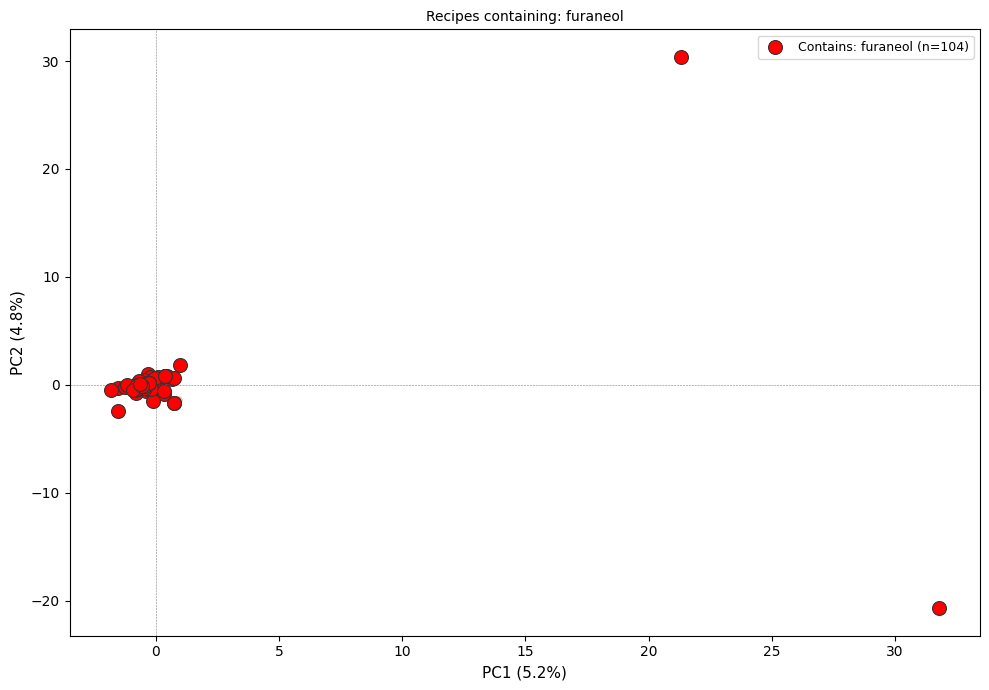

In [24]:
# ── Demo: Furaneol – the key strawberry character odorant ────────────────────
# 3658-77-3 = 2,5-dimethyl-4-hydroxy-3(2H)-furanone (Furaneol / DMHF)
_ = find_by_ingredient('furaneol', n_top=15, plot=True)

Top PC2 driver: 3390-12-3 – Acetaldehyd PG acetal

Matched 1 CAS number(s):
  3390-12-3  -->  Acetaldehyd PG acetal

Present in 2 / 129 recipes.

          Norm_Total     PC1     PC2    PC3 Dom. OT
Rez.-Nr.                                           
185.309P    0.014409  21.336  30.386  1.887  fruity
185.748P    0.000014   0.975   1.805 -1.903  fruity



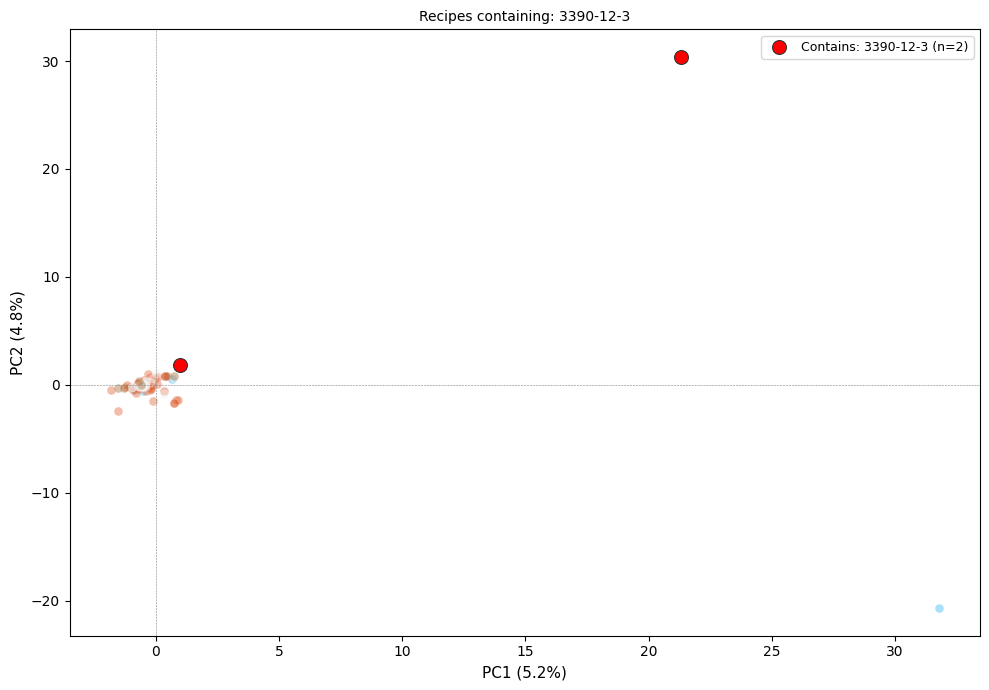

In [25]:
# ── Demo: top PC2 driver ingredient ─────────────────────────────────────────
top_pc2_cas = cas_labels[np.argmax(np.abs(loadings[1]))]
print(f'Top PC2 driver: {top_pc2_cas} – {cas_name.get(top_pc2_cas, "?")}')
print()
_ = find_by_ingredient(top_pc2_cas, n_top=15, plot=True)

---
## 10 · Virtual Recipe → Nearest Real Recipes

**Inverse search:** specify any combination of ingredients and amounts → the model
projects them into PCA space and returns the closest real recipes.

This answers: *"If I build a recipe with these key odorants, which existing recipes
am I closest to — and which odour type family does that land me in?"*

In [26]:
def nearest_recipes(ingredient_dict, n=10, plot=True, label="Virtual Recipe"):
    # Find the nearest real recipes to a virtual recipe.
    # ingredient_dict: {cas_or_name_fragment: norm_proportion}
    # Values are normalised proportions (will be auto-normalised to sum=1).
    resolved = {}
    for key, amt in ingredient_dict.items():
        if key in cas_labels:
            resolved[key] = amt
        else:
            hit = next(
                (c for c in cas_labels if key.lower() in cas_name.get(c, "").lower()),
                None
            )
            if hit:
                resolved[hit] = amt
            else:
                print(f"  WARNING: {key!r} not found in model - skipped.")

    if not resolved:
        print("No valid ingredients after resolution. Aborting.")
        return None

    print(f"  {label}  -  resolved {len(resolved)} ingredient(s):")
    for cas, amt in resolved.items():
        print(f"    {cas:15s}  {cas_name.get(cas, cas).split(',')[0][:40]:40s}  norm={amt:.6f}")
    print()

    virt_vec = np.zeros(len(cas_labels))
    for cas, amt in resolved.items():
        virt_vec[cas_labels.index(cas)] = max(0.0, float(amt))

    if virt_vec.sum() > 0:
        virt_vec /= virt_vec.sum()

    virt_scaled = scaler_oav.transform(virt_vec.reshape(1, -1))[0]
    virt_score  = pca_oav.transform(virt_scaled.reshape(1, -1))[0]

    print(f"  Virtual recipe in PCA space: "
          f"PC1={virt_score[0]:+.3f}  PC2={virt_score[1]:+.3f}  PC3={virt_score[2]:+.3f}")
    print()

    dists  = np.linalg.norm(scores_oav - virt_score, axis=1)
    nn_idx = np.argsort(dists)[:n]

    result_rows = []
    print(f"  {n} nearest real recipes:")
    for rank, ri in enumerate(nn_idx, 1):
        result_rows.append({
            "Rank":     rank,
            "Rez.-Nr.": recipes_oav[ri],
            "Distance": round(dists[ri], 3),
            "PC1":      round(scores_oav[ri, 0], 3),
            "PC2":      round(scores_oav[ri, 1], 3),
            "PC3":      round(scores_oav[ri, 2], 3),
            "Dom. OT":  dom_ot_labels[ri],
        })
        print(f"    #{rank:2d}  {recipes_oav[ri]:12s}  dist={dists[ri]:.3f}"
              f"  PC1={scores_oav[ri,0]:+.2f}  PC2={scores_oav[ri,1]:+.2f}"
              f"  ({dom_ot_labels[ri]})")

    result_df = pd.DataFrame(result_rows).set_index("Rank")

    if plot:
        fig, ax = plt.subplots(figsize=(11, 8))
        for ot in sorted(set(dom_ot_labels)):
            mask = np.array(dom_ot_labels) == ot
            ax.scatter(scores_oav[mask, 0], scores_oav[mask, 1],
                       c=ODOUR_PALETTE.get(ot, "#BBBBBB"),
                       s=42, alpha=0.50, edgecolors="white", linewidths=0.3, zorder=2)
        ax.scatter(scores_oav[nn_idx, 0], scores_oav[nn_idx, 1],
                   s=130, facecolors="none", edgecolors="#111", linewidths=1.8,
                   zorder=4, label=f"Top {n} nearest")
        for rank, ri in enumerate(nn_idx, 1):
            ax.annotate(f"#{rank} {recipes_oav[ri]}", (scores_oav[ri, 0], scores_oav[ri, 1]),
                        fontsize=7, xytext=(6, 4), textcoords="offset points")
        ax.scatter(virt_score[0], virt_score[1],
                   marker="*", s=380, c="gold", edgecolors="#333", linewidths=1.2,
                   zorder=5, label=label)
        ax.annotate(label, (virt_score[0], virt_score[1]), fontsize=9, fontweight="bold",
                    xytext=(9, 7), textcoords="offset points")
        ax.axhline(0, color="grey", lw=0.4, ls="--")
        ax.axvline(0, color="grey", lw=0.4, ls="--")
        ax.set_xlabel(f"PC1 ({ev[0]:.1f}%)", fontsize=11)
        ax.set_ylabel(f"PC2 ({ev[1]:.1f}%)", fontsize=11)
        ax.set_title(
            f"Nearest Real Recipes to: {label}\n"
            f"({len(resolved)} ingredient(s) specified | {n} nearest shown)",
            fontsize=10
        )
        ax.legend(fontsize=9)
        plt.tight_layout()
        safe = label[:25].replace(" ", "_").replace("/", "-").replace("+", "x")
        fig.savefig(OUT_DIR / f"pca_v2_nearest_{safe}.png", dpi=150, bbox_inches="tight")
        plt.show()

    return result_df

print("nearest_recipes() defined.")
print('Usage:  nearest_recipes({"furaneol": 0.30, "vanillin": 0.10, "linalool": 0.05})')


nearest_recipes() defined.
Usage:  nearest_recipes({"furaneol": 0.30, "vanillin": 0.10, "linalool": 0.05})


Demo virtual recipe (top-3 PC1 ingredients at median normalised proportion):
  120-51-4  Benzylbenzoat Halal  norm=0.015256
  97-53-0  Eugenol Halal  norm=0.000039
  124-19-6  Nonanal  norm=0.000216

  PC1 Dominant Mix  -  resolved 3 ingredient(s):
    120-51-4         Benzylbenzoat Halal                       norm=0.015256
    97-53-0          Eugenol Halal                             norm=0.000039
    124-19-6         Nonanal                                   norm=0.000216

  Virtual recipe in PCA space: PC1=+291.773  PC2=-127.927  PC3=+5.302

  10 nearest real recipes:
    # 1  187.004P      dist=282.836  PC1=+31.78  PC2=-20.71  (fresh)
    # 2  185.309P      dist=314.998  PC1=+21.34  PC2=+30.39  (fruity)
    # 3  186.985P      dist=318.657  PC1=+0.90  PC2=-1.42  (fruity)
    # 4  185.902P      dist=318.898  PC1=+0.82  PC2=-1.41  (fruity)
    # 5  185.339P      dist=319.493  PC1=+0.35  PC2=-0.88  (odorless)
    # 6  187.772       dist=319.822  PC1=+0.72  PC2=+0.80  (warm)
    # 7  1

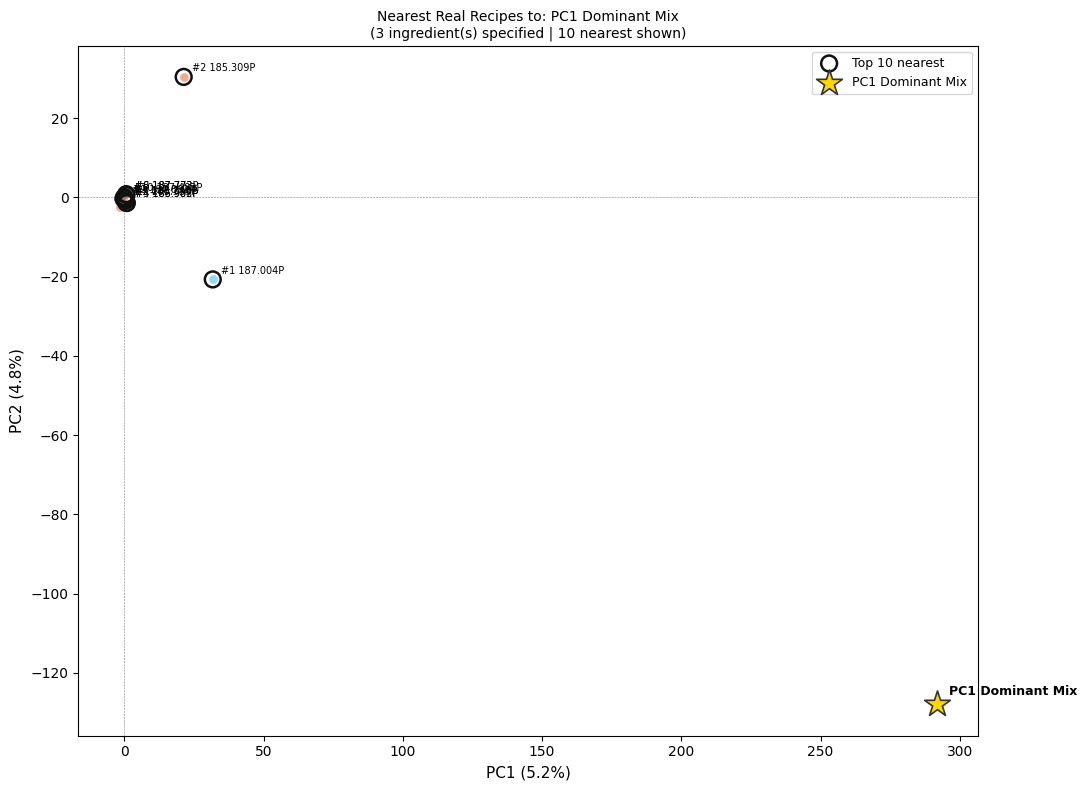

In [27]:
# -- Demo 1: auto-build virtual recipe from top PC1 ingredients --------------
top3_pc1_idx = np.argsort(np.abs(loadings[0]))[::-1][:3]
top3_pc1_cas = [cas_labels[i] for i in top3_pc1_idx]

# Use median normalised proportion across recipes that contain each ingredient
pc1_mix = {}
for cas in top3_pc1_cas:
    if cas not in pivot_oav.columns:
        continue
    vals = pivot_oav.loc[pivot_oav[cas] > 0, cas]
    if len(vals) == 0:
        continue
    pc1_mix[cas] = float(vals.median())

print("Demo virtual recipe (top-3 PC1 ingredients at median normalised proportion):")
for cas, amt in pc1_mix.items():
    print(f"  {cas}  {cas_name.get(cas, '?').split(',')[0][:40]}  norm={amt:.6f}")
print()
_ = nearest_recipes(pc1_mix, n=10, label="PC1 Dominant Mix")


  Furaneol + Vanillin + Linalool  -  resolved 3 ingredient(s):
    27538-09-6       Ethylfuraneol Kosher Halal                norm=0.300000
    121-33-5         Vanillin ex Eugenol                       norm=0.100000
    1365-19-1        Linalooloxid                              norm=0.050000

  Virtual recipe in PCA space: PC1=+1.539  PC2=-24.830  PC3=+1.950

  10 nearest real recipes:
    # 1  185.748P      dist=218.006  PC1=+0.97  PC2=+1.80  (fruity)
    # 2  185.028       dist=226.939  PC1=+0.65  PC2=+0.55  (fresh)
    # 3  187.894P      dist=228.726  PC1=-0.10  PC2=-1.46  (fruity)
    # 4  187.796P      dist=231.325  PC1=-0.57  PC2=+0.17  (fruity)
    # 5  187.773P      dist=233.473  PC1=+0.74  PC2=+0.60  (odorless)
    # 6  187.482P      dist=233.590  PC1=+0.75  PC2=-1.69  (fruity)
    # 7  185.382P      dist=233.590  PC1=+0.75  PC2=-1.69  (fruity)
    # 8  186.395P      dist=233.729  PC1=+0.44  PC2=+0.84  (warm)
    # 9  186.981P      dist=233.795  PC1=-0.22  PC2=-0.52  (fruity)

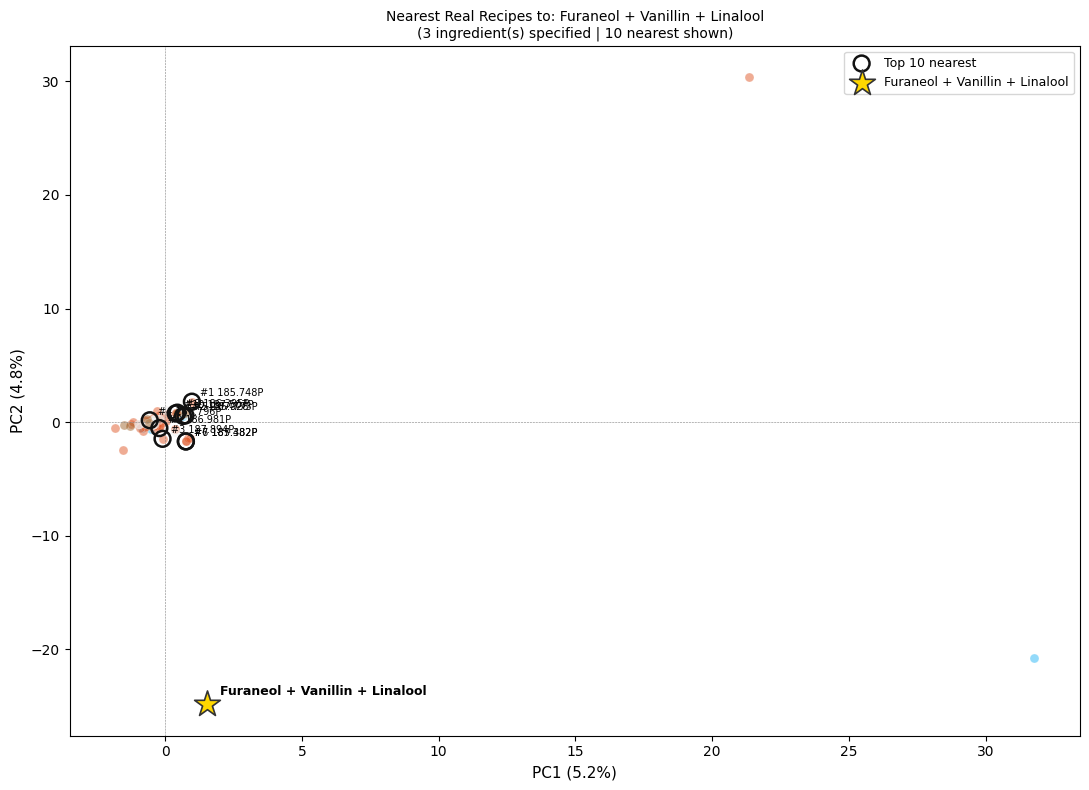

In [28]:
# -- Demo 2: freely-defined mix (edit to explore) ----------------------------
# Keys can be partial ingredient names (case-insensitive) or exact CAS numbers.
# Values are normalised proportions (will be auto-normalised to sum=1).
my_mix = {
    "furaneol":  0.30,    # key strawberry character odorant
    "vanillin":  0.10,    # warm vanilla support
    "linalool":  0.05,    # floral/fresh lift
}
_ = nearest_recipes(my_mix, n=10, label="Furaneol + Vanillin + Linalool")


---
## 11 · Full Contribution Heatmap + Attribution Export

A complete view of which ingredients drive which recipes across PC1 and PC2,
plus a CSV export with the top-5 ingredient drivers per PC for every recipe.

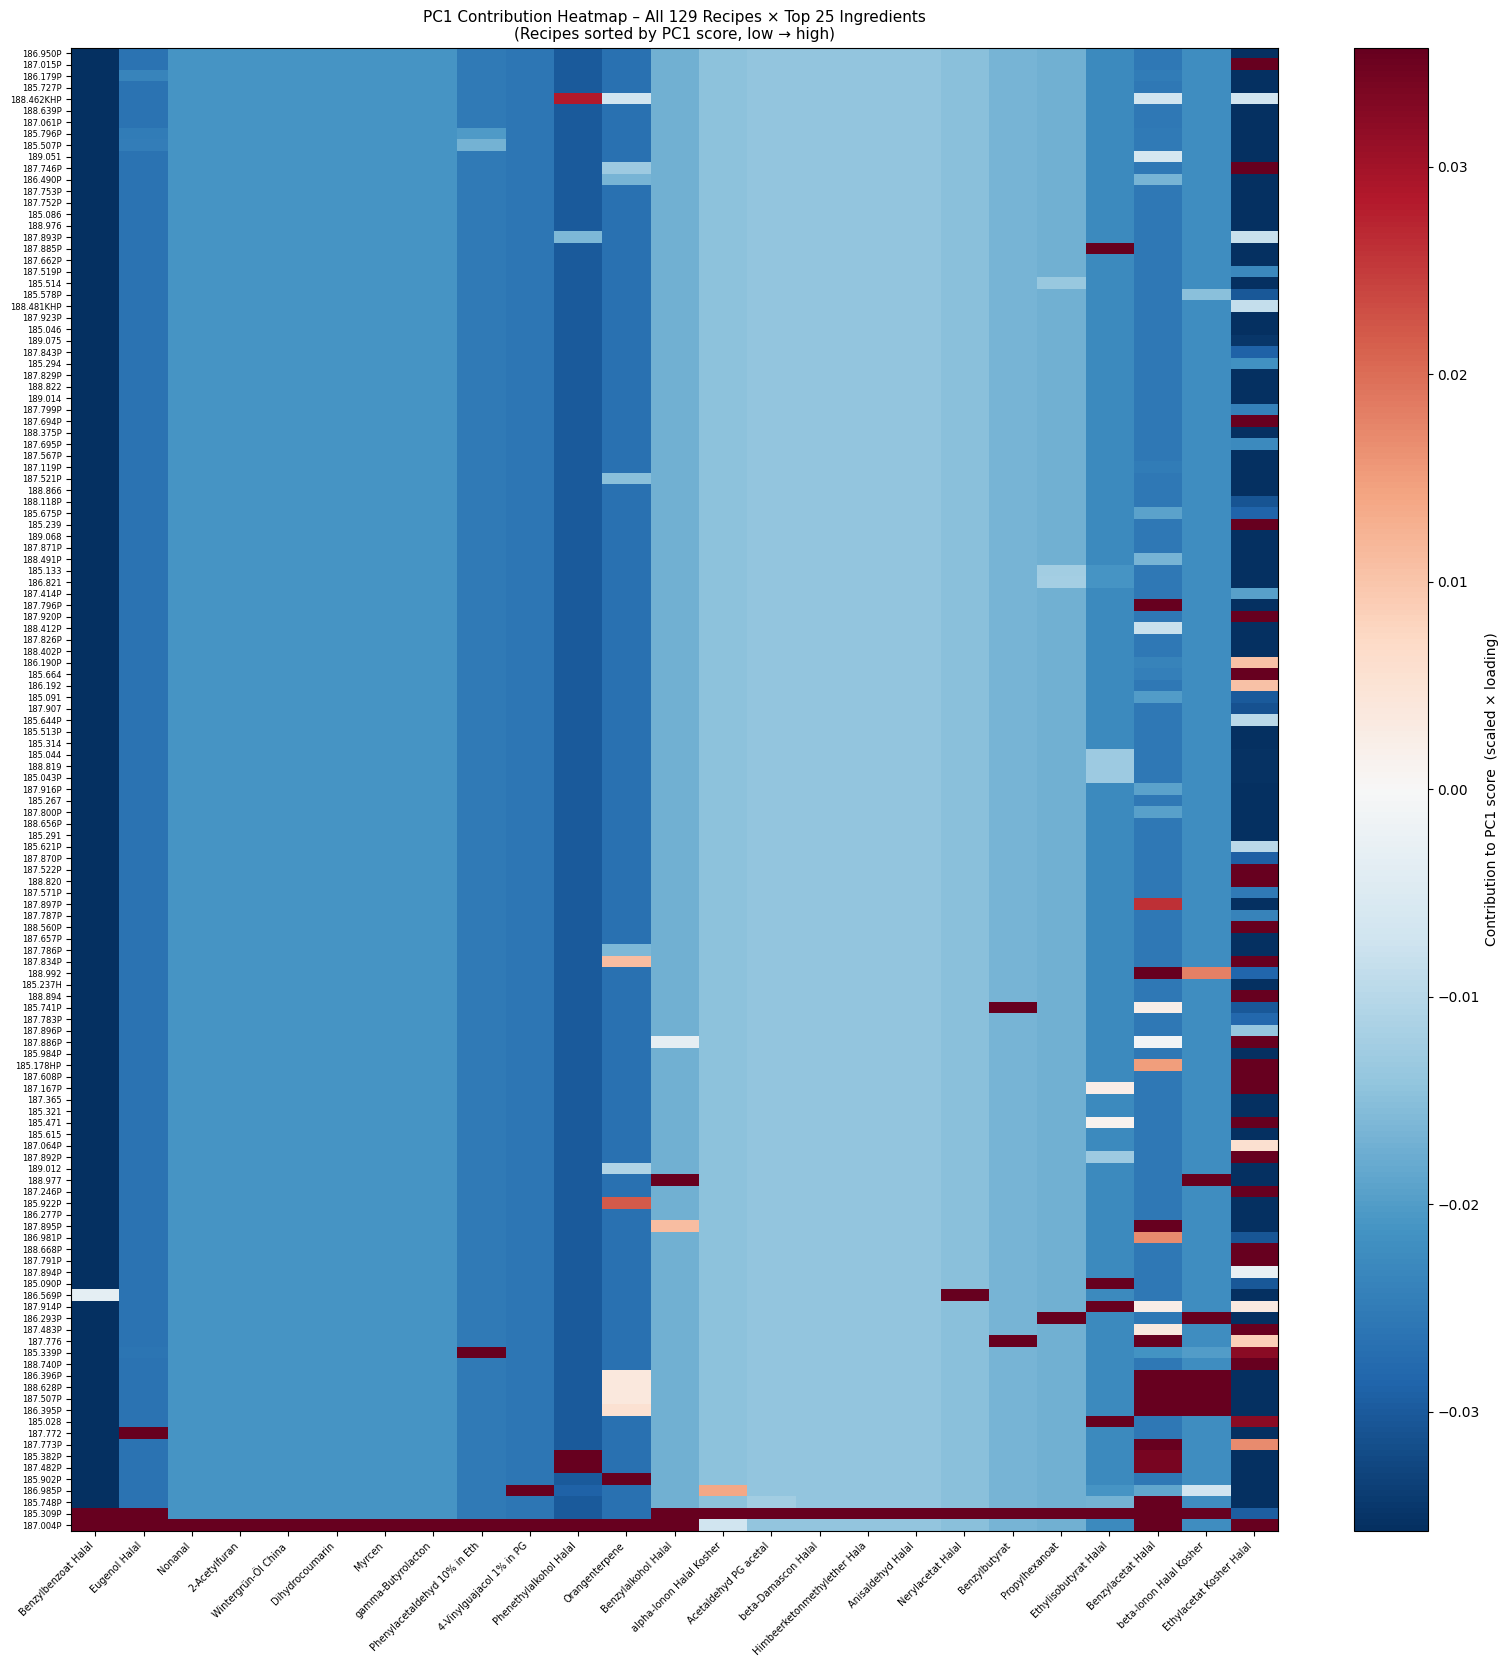

Saved: pca_v2_contrib_heatmap_pc1.png


In [29]:
# ── PC1 contribution heatmap – all recipes × top-25 ingredients ─────────────
N_ING_HEAT = 25

top25_idx  = np.argsort(np.abs(loadings[0]))[::-1][:N_ING_HEAT]
top25_cas  = [cas_labels[i] for i in top25_idx]
top25_lbl  = [cas_name.get(c, c).split(',')[0][:28] for c in top25_cas]

# Contribution of each ingredient to each recipe's PC1 score: (n_recipes, 25)
contrib_pc1 = contrib[:, 0, :][:, top25_idx]

# Sort recipes by PC1 score (low to high) for readability
order = np.argsort(scores_oav[:, 0])
contrib_sorted = contrib_pc1[order]
recipe_labels_sorted = [recipes_oav[i] for i in order]

fig, ax = plt.subplots(figsize=(16, max(8, len(recipes_oav) * 0.13)))
vmax = np.percentile(np.abs(contrib_sorted), 95)
im = ax.imshow(
    contrib_sorted, aspect='auto', cmap='RdBu_r',
    vmin=-vmax, vmax=vmax, interpolation='nearest'
)
ax.set_xticks(range(N_ING_HEAT))
ax.set_xticklabels(top25_lbl, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(recipes_oav)))
ax.set_yticklabels(recipe_labels_sorted, fontsize=6)
plt.colorbar(im, ax=ax, label='Contribution to PC1 score  (scaled × loading)')
ax.set_title(
    f'PC1 Contribution Heatmap – All {len(recipes_oav)} Recipes × Top {N_ING_HEAT} Ingredients\n'
    '(Recipes sorted by PC1 score, low → high)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_contrib_heatmap_pc1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_contrib_heatmap_pc1.png')

In [30]:
# ── Export: per-recipe top-5 ingredient driver per PC → CSV ─────────────────
export_rows = []
for r_idx, rez in enumerate(recipes_oav):
    row = {'Rez.-Nr.': rez, 'Dom_OT': dom_ot_labels[r_idx]}
    for k in range(N_PC_ATTR):
        c_vec = contrib[r_idx, k]
        top5  = np.argsort(np.abs(c_vec))[::-1][:5]
        row[f'PC{k+1}_score'] = round(scores_oav[r_idx, k], 4)
        for rank, i in enumerate(top5, 1):
            cas  = cas_labels[i]
            name = cas_name.get(cas, cas).split(',')[0][:35]
            row[f'PC{k+1}_top{rank}_cas']     = cas
            row[f'PC{k+1}_top{rank}_name']    = name
            row[f'PC{k+1}_top{rank}_contrib']  = round(float(c_vec[i]), 5)
    export_rows.append(row)

attr_df = pd.DataFrame(export_rows).set_index('Rez.-Nr.')
attr_df.to_csv(OUT_DIR / 'pca_v2_recipe_attribution.csv')
print('Exported: pca_v2_recipe_attribution.csv')
print(f'Shape: {attr_df.shape}  ({len(export_rows)} recipes × {attr_df.shape[1]} columns)')
print()
print('Preview (first 4 recipes, first 12 columns):')
print(attr_df.iloc[:4, :12].to_string())

Exported: pca_v2_recipe_attribution.csv
Shape: (129, 65)  (129 recipes × 65 columns)

Preview (first 4 recipes, first 12 columns):
            Dom_OT  PC1_score PC1_top1_cas          PC1_top1_name  PC1_top1_contrib PC1_top2_cas                  PC1_top2_name  PC1_top2_contrib PC1_top3_cas             PC1_top3_name  PC1_top3_contrib PC1_top4_cas
Rez.-Nr.                                                                                                                                                                                                               
185.028      fresh     0.6504      97-62-1  Ethylisobutyrat Halal           0.56216      78-70-6                 Linalool ex HO           0.22306     503-74-2    Isovaleriansäure Halal           0.09086     140-10-3
185.043P  odorless    -0.5093     586-62-9             Terpinolen          -0.04340     120-51-4            Benzylbenzoat Halal          -0.03574     141-78-6  Ethylacetat Kosher Halal          -0.03545      60-12-8
185.0

---
## 12 · Top 20 Ingredients per Recipe (PCA Contribution Export)

For every recipe the 20 ingredients that contribute most to its PCA fingerprint are ranked.
The `Norm_Totalmenge` column shows the **normalised relative proportion** within the recipe (no log, no OAV).


In [31]:
# -- Top 20 ingredients per recipe by combined PCA contribution ---------------
# Only include ingredients ACTUALLY present in the recipe (Norm_Totalmenge > 0).
# PCA standardisation can produce non-zero contributions for absent ingredients
# (because absence is encoded as a negative scaled value); those are excluded here.
total_abs_contrib = np.abs(contrib).sum(axis=1)  # (n_recipes, n_cas)

N_TOP_PER_RECIPE = 20
rows = []
for r_idx, rez in enumerate(recipes_oav):
    # Restrict to ingredients that are actually present in this recipe
    present_mask = pivot_oav.iloc[r_idx].values > 0
    present_idx  = np.where(present_mask)[0]

    if len(present_idx) == 0:
        continue

    # Rank present ingredients by total |contrib|, take top 20
    contribs_present = total_abs_contrib[r_idx][present_idx]
    top_k            = min(N_TOP_PER_RECIPE, len(present_idx))
    top_local        = np.argsort(contribs_present)[::-1][:top_k]
    top_idx          = present_idx[top_local]

    for rank, i in enumerate(top_idx, 1):
        cas = cas_labels[i]
        rows.append({
            "Rez.-Nr.":        rez,
            "Dom_OT":          dom_ot_labels[r_idx],
            "Rank":            rank,
            "CAS":             cas,
            "Ingredient":      cas_name.get(cas, cas),
            "Norm_Totalmenge": round(float(pivot_oav.iloc[r_idx, i]), 6),
            "Total_Contrib":   round(float(total_abs_contrib[r_idx, i]), 5),
            "PC1_Contrib":     round(float(contrib[r_idx, 0, i]), 5),
            "PC2_Contrib":     round(float(contrib[r_idx, 1, i]), 5),
            "PC3_Contrib":     round(float(contrib[r_idx, 2, i]), 5),
            "PC4_Contrib":     round(float(contrib[r_idx, 3, i]), 5),
        })

top20_df = pd.DataFrame(rows)
n_recipes_in = top20_df["Rez.-Nr."].nunique()
avg_per = len(top20_df) / n_recipes_in if n_recipes_in else 0
print(f"Shape: {top20_df.shape}  ({n_recipes_in} recipes, avg {avg_per:.1f} ingredients/recipe)")
print(f"All Norm_Totalmenge > 0: {(top20_df.Norm_Totalmenge > 0).all()}")
print()

xlsx_path = OUT_DIR / "pca_v2_top20_ingredients_per_recipe.xlsx"
csv_path  = OUT_DIR / "pca_v2_top20_ingredients_per_recipe.csv"
top20_df.to_excel(xlsx_path, index=False)
top20_df.to_csv(csv_path, index=False)
print(f"Exported: {xlsx_path.name}")
print(f"Exported: {csv_path.name}")
print()
display(top20_df.head(30))


Shape: (2344, 11)  (129 recipes, avg 18.2 ingredients/recipe)
All Norm_Totalmenge > 0: False

Exported: pca_v2_top20_ingredients_per_recipe.xlsx
Exported: pca_v2_top20_ingredients_per_recipe.csv



,Rez.-Nr.,Dom_OT,Rank,CAS,Ingredient,Norm_Totalmenge,Total_Contrib,PC1_Contrib,PC2_Contrib,PC3_Contrib,PC4_Contrib
0,185.028,fresh,1,97-62-1,Ethylisobutyrat Halal,0.003501,1.51250,0.56216,0.88338,0.05006,0.01690
1,185.028,fresh,2,6728-26-3,trans-2-Hexenal Kosher Halal,0.003889,0.75796,0.00821,-0.04129,-0.18458,0.52388
2,185.028,fresh,3,78-70-6,"Linalool ex HO, natürlich Kosher Halal BG",0.005445,0.60283,0.22306,-0.19366,0.16129,0.02482
3,185.028,fresh,4,27625-35-0,"Isoamyl-2-methylbutyrat, natürlich",0.001945,0.49667,0.00764,-0.02522,-0.12365,0.34016
4,185.028,fresh,5,3025-30-7,"Ethyl-trans,cis-2,4-decadienoat, natürlich Halal",0.003112,0.41504,0.03280,0.04268,-0.09061,-0.24894
5,185.028,fresh,6,140-10-3,"Zimtsäure, natürlich",0.000324,0.38061,0.05540,0.05144,-0.10011,-0.17366
6,185.028,fresh,7,23696-85-7,"beta-Damascenon, natürlich Kosher Halal",0.000138,0.38061,0.05540,0.05144,-0.10011,-0.17366
7,185.028,fresh,8,75-07-0,Acetaldehyd Halal Kosher,0.125631,0.38004,0.01143,0.03413,-0.08976,-0.24471
8,185.028,fresh,9,10032-15-2,Hexyl-2-methylbutyrat Halal Kosher,0.000778,0.35491,-0.03135,-0.00632,-0.12912,0.18813
9,185.028,fresh,10,705-86-2,delta-Decalacton Halal Kosher,0.001719,0.33793,-0.00395,0.04459,-0.07078,-0.21861


---
## 13 · Top 20 Ingredients Globally (Across All Recipes)

These are the ingredients with the highest **summed absolute PCA contribution** across all recipes and all four principal components - i.e. the most analytically impactful substances in the entire portfolio regardless of which recipe they come from.


=== Top 20 Ingredients Globally (all recipes combined) ===

 Rank        CAS                                Ingredient  Global_Importance  Frequency  Avg_Norm_Present  Avg_Norm_All  Recipes_Count  PC1_Loading  PC2_Loading  PC3_Loading  PC4_Loading
    1   142-92-7                  Hexylacetat Kosher Halal            29.6281     0.5116          0.008638      0.004419             66       0.0048      -0.0228      -0.0971       0.2674
    2   659-70-1            Isoamylisovalerat Kosher Halal            28.9910     0.3798          0.011154      0.004237             49      -0.0088      -0.0165      -0.0890       0.2448
    3   108-64-5              Ethylisovalerat Kosher Halal            26.4767     0.5814          0.015013      0.008728             75       0.0431       0.0881      -0.0513       0.1321
    4   106-27-4                      Isoamylbutyrat Halal            21.2149     0.1938          0.009425      0.001827             25      -0.0015      -0.0174      -0.0871       0.2380


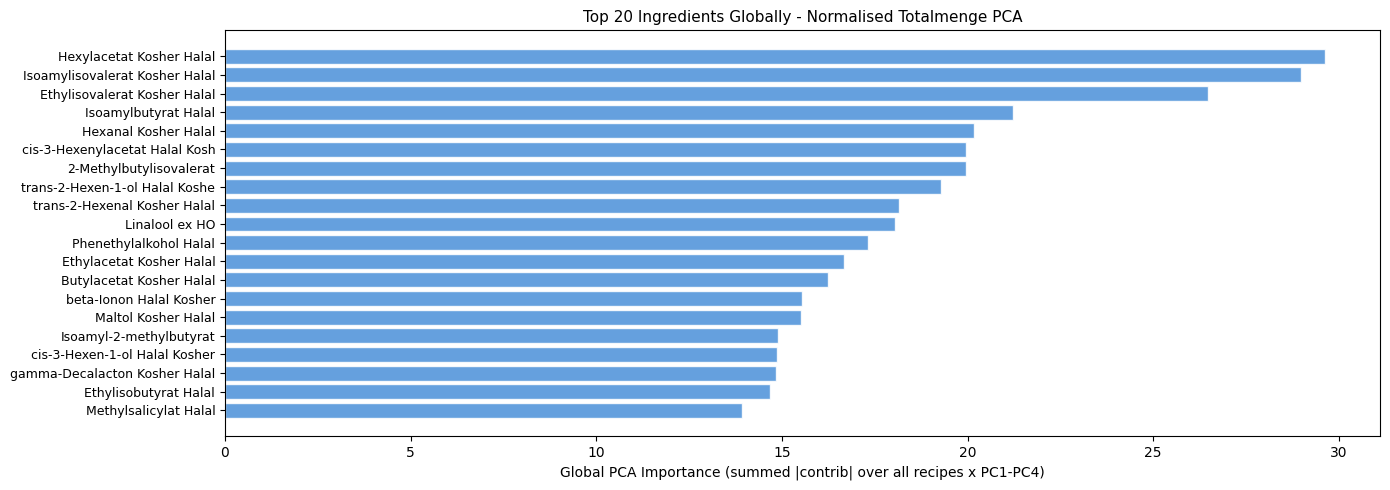

Saved: pca_v2_top20_global_importance.png


In [32]:
# -- Top 20 Ingredients Globally (summed |contrib| over all recipes x PC1-PC4) -
global_importance = np.abs(contrib).sum(axis=(0, 1))   # (n_cas,)

top20_global_idx = np.argsort(global_importance)[::-1][:20]

global_rows = []
for rank, i in enumerate(top20_global_idx, 1):
    cas = cas_labels[i]
    col = pivot_oav.iloc[:, i]
    global_rows.append({
        "Rank":              rank,
        "CAS":               cas,
        "Ingredient":        cas_name.get(cas, cas),
        "Global_Importance": round(float(global_importance[i]), 4),
        "Frequency":         round(float((col > 0).mean()), 4),
        "Avg_Norm_Present":  round(float(col[col > 0].mean() if (col > 0).any() else 0), 6),
        "Avg_Norm_All":      round(float(col.mean()), 6),
        "Recipes_Count":     int((col > 0).sum()),
        "PC1_Loading":       round(float(loadings[0, i]), 4),
        "PC2_Loading":       round(float(loadings[1, i]), 4),
        "PC3_Loading":       round(float(loadings[2, i]), 4),
        "PC4_Loading":       round(float(loadings[3, i]), 4),
    })

top20_global_df = pd.DataFrame(global_rows)
print("=== Top 20 Ingredients Globally (all recipes combined) ===")
print()
print(top20_global_df.to_string(index=False))

top20_global_df.to_csv(OUT_DIR / "pca_v2_top20_ingredients_global.csv", index=False)
top20_global_df.to_excel(OUT_DIR / "pca_v2_top20_ingredients_global.xlsx", index=False)
print("\nExported: pca_v2_top20_ingredients_global.csv / .xlsx")

# -- Quick bar chart of global importance ---------------------------------
names_short = [cas_name.get(cas_labels[i], cas_labels[i]).split(",")[0][:30]
               for i in top20_global_idx]
fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(range(20), global_importance[top20_global_idx][::-1],
        color="#4A90D9", alpha=0.85, edgecolor="white")
ax.set_yticks(range(20))
ax.set_yticklabels(names_short[::-1], fontsize=9)
ax.set_xlabel("Global PCA Importance (summed |contrib| over all recipes x PC1-PC4)")
ax.set_title("Top 20 Ingredients Globally - Normalised Totalmenge PCA", fontsize=11)
plt.tight_layout()
fig.savefig(OUT_DIR / "pca_v2_top20_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_v2_top20_global_importance.png")


---
## 14 · Key Findings (v2 - No Threshold)

### Data Processing
- Ignore list applied (CAS-based masking) before any analysis.
- Totalmenge normalised per recipe to relative proportions (sum = 1).
- **No OAV / olfactory threshold** used.
- **No log transformation** - proportions are already on a comparable scale.

### Ingredient Statistics
- Frequency and average proportion per ingredient computed across all recipes.
- Full statistics exported to `pca_v2_ingredient_statistics.csv`.

### PCA Results
- Top 20 ingredients per recipe: `pca_v2_top20_ingredients_per_recipe.csv`.
- Top 20 globally: `pca_v2_top20_ingredients_global.csv`.


## Summary

| | Value |
|---|---|
| Recipes analysed | 129 |
| Ingredients with OAV | 130 CAS |
| PC1 explained variance | — |
| PC2 explained variance | — |
| PC1+PC2 cumulative | — |

**Key observations (fill in after running):**
- Which odour types cluster together?
- Which ingredients drive PC1 vs PC2?
- Are there outlier recipes?

**Output files:**
- `outputs/pca_v1_scree_oav.png`
- `outputs/pca_v1_pc1pc2_oav.png`
- `outputs/pca_v1_biplot_oav.png`
- `outputs/pca_v1_odourtype_biplot.png`
- `outputs/pca_v1_dashboard_pc123.png`
- `outputs/pca_v1_loading_heatmap.png`
- `outputs/pca_v1_scores.csv`